# Importação de bibliotecas

In [1]:
# 1. Bibliotecas nativas do Python
import os
import math
import warnings

# 2. Bibliotecas de terceiros (manipulação de dados e redes)
import numpy as np
import pandas as pd
import networkx as nx
import networkx.algorithms.community as nx_comm

# 3. Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Ferramentas e métricas específicas
from unidecode import unidecode
from sklearn.metrics import mean_squared_error

# Configuração de caminhos e dicionários

In [2]:
# ==============================================================================
# 1. CONFIGURAÇÕES GLOBAIS E DE VISUALIZAÇÃO
# ==============================================================================
# Ignora avisos não críticos para manter o output limpo
warnings.filterwarnings("ignore")

# Configuração visual padrão para todos os gráficos do notebook
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ==============================================================================
# 2. CONFIGURAÇÃO DE CAMINHOS (PATHS) E PARÂMETROS GERAIS
# ==============================================================================
BASE_PATH = '../data'

# Entradas (Inputs)
PATH_NAMES = f'{BASE_PATH}/raw/researchers_names.txt'
DIR_MATRIZES = f'{BASE_PATH}/raw/adjacency_matrices' # Ajuste este caminho se necessário
PATH_AREAS = f'{BASE_PATH}/processed/lattes_looker_studio.csv'
PATH_SUGESTOES = f'{BASE_PATH}/processed/similarity_matrices/suggestions_filtered.parquet'

# Parâmetros de execução
YEARS = range(2016, 2026)
SUGGEST_THRESHOLD = 0.2264

# ==============================================================================
# 3. CARREGAMENTO DE METADADOS (NÓS E ÁREAS)
# ==============================================================================
print(">>> Carregando Metadados (nomes e áreas)...")

# Leitura dos nomes (índices do grafo)
nomes_df = pd.read_table(PATH_NAMES, header=None)
researchers = nomes_df[0].apply(lambda x: unidecode(str(x).strip())).tolist()

# Leitura das áreas e criação de um dicionário mapeado
df_areas = pd.read_csv(PATH_AREAS, sep=';')
df_areas['Pesquisador'] = df_areas['Pesquisador'].apply(lambda x: unidecode(str(x).strip()))
areas_dict = dict(zip(df_areas['Pesquisador'], df_areas['Área']))

print(f"✅ Total de {len(researchers)} pesquisadores mapeados nas áreas.")

# ==============================================================================
# 4. MAPEAMENTO E HIGIENIZAÇÃO DE TITULAÇÕES
# ==============================================================================
print(">>> Carregando e higienizando dicionário de Titulações...")

# Dicionário bruto de titulações
education_raw_dict = {
    'Adriano Jose Ferruzzi' : 'Mestrado',
    'Adriana Paes de Jesus Correia' : 'Mestrado',
    'Alan Marques da Silva' : 'Mestrado',
    'Aldemir Versani de Souza Callou' : 'Especialização',
    'Alessandra da Silva Carneiro' : 'Doutorado',
    'Alessandro Emilio Teruzzi' : 'Doutorado',
    'Alex Sandro Rodrigues Ancioto' : 'Mestrado',
    'Alexandre Dias Paza' : 'Doutorado',
    'Alexandre José Romagnoli' : 'Doutorado',
    'Alexandre Machado Rosa' : 'Doutorado',
    'Ana Carolina Vila Ramos dos Santos' : 'Doutorado',
    'Ana Claudia Folha da Cruz' : 'Graduação',
    'Ana Lúcia Pereira da silva Souza' : 'Especialização',
    'Ana Márcia Lima Costa' : 'Doutorado',
    'Ana Paula Bulgarelli' : 'Mestrado',
    'Ana Paula Fabro de Oliveira' : 'Doutorado',
    'Ana Paula Rodrigues Magalhães de Barros' : 'Doutorado',
    'Ana Paula Santos da Conceição' : 'Doutorado',
    'André Luiz Favareto' : 'Mestrado',
    'Andréa Antonieta Cotrim Silva' : 'Doutorado',
    'Ariane Macedo Melo Ferraz' : 'Doutorado',
    'Arthur Muramoto Hayashi' : 'Especialização',
    'Beethoven Adriano de Souza' : 'Mestrado',
    'Beatriz Ferraz Diniz' : 'Doutorado',
    'Bianca Blanco' : 'Especialização',
    'Bruno Oliveira Ferreira' : 'Especialização',
    'Bruno Secco Faquin' : 'Doutorado',
    'Bruno Sérgio do Amaral' : 'Doutorado',
    'Bárbara Beatriz Freitag' : 'Doutorado',
    'Bárbara Cavichioli' : 'Graduação',
    'Carla Laís Fileto de Held' : 'Graduação',
    'Carolina Aparecida de Freitas Dias' : 'Doutorado',
    'Caroline Inês Lisevski' : 'Doutorado',
    'Claudia Almerinda de Souza Oliveira' : 'Doutorado',
    'Cláudio Roberto da Silva Alexandre' : 'Especialização',
    'Cristiane Rodrigues de Viveiros' : 'Especialização',
    'Cynthia Regina Fischer' : 'Doutorado',
    'Danilo Amorim de Souza' : 'Doutorado',
    'Danilo Marcondes de Alcantara' : 'Doutorado',
    'Davi Munhoz Benati' : 'Doutorado',
    'Edineia Lazaro Souza Valerio' : 'Graduação',
    'Edna Alencar da Silva Rivera' : 'Doutorado',
    'Eliane Maria Crepaldi' : 'Especialização',
    'Elide Gomes Pereti Cremonesi' : 'Especialização',
    'Elisangela Lizardo de Oliveira' : 'Doutorado',
    'Emanoel Fabiano Menezes Pereira' : 'Mestrado',
    'Ester Kolling Rodrigues' : 'Especialização',
    "Eudes Müller D'Oliveira Santos" : 'Doutorado',
    'Eufrida Pereira da Silva' : 'Doutorado',
    'Everaldo Paulo da Silva' : 'Mestrado',
    'Fabio Oliveira Teixeira' : 'Doutorado',
    'Felipe Alexandre Cardoso Pazinatto' : 'Doutorado',
    'Felipe Rodrigues Martinez Basile' : 'Doutorado',
    'Fernanda Batista de Andrade' : 'Ensino Médio',
    'Fernando Cesar Mendonca' : 'Mestrado',
    'Fernando Luis Rossi' : 'Doutorado',
    'Fernando da Silva Pardo' : 'Doutorado',
    'Filipe Mantovani Ferreira' : 'Doutorado',
    'Flávia Roberta Torezin' : 'Doutorado',
    'Francisco Manoel Filho' : 'Doutorado',
    'Gildete Mamede Sales' : 'Especialização',
    'Giovana Moreira da Costa' : 'Mestrado',
    'Hadassa Viviane Rodrigues' : 'Mestrado',
    'Hamilton Carvalho da Silva' : 'Mestrado',
    'Hania Cecília Pilan' : 'Doutorado',
    'Idalise Bernardo Bagé' : 'Doutorado',
    'Iderval Alves Barbosa' : 'Doutorado',
    'Igor Calebe Zadi' : 'Mestrado',
    'Igor Polezi Munhoz' : 'Mestrado',
    'Ingrid Anelise Lopes' : 'Doutorado',
    'Irando Alves Martins Neto' : 'Doutorado',
    'Ivan Miletovic Mozol' : 'Mestrado',
    'Jair Garcia dos Santos' : 'Especialização',
    'Jairo Filho Sousa de Almeida Ferreira' : 'Mestrado',
    'Jeferson Antunes' : 'Doutorado',
    'Jose Osorio de Oliveira Azevedo Neto' : 'Doutorado',
    'José Cícero Calheiros' : 'Mestrado',
    'José Geraldo Basante' : 'Doutorado',
    'José Roberto Campanele' : 'Mestrado',
    'Joyce Martins Mendes' : 'Doutorado',
    'Juliana de Souza Topan' : 'Doutorado',
    'Junot de Oliveira Maia' : 'Doutorado',
    'Júlio Samuel Sávio Bernardo' : 'Doutorado',
    'Kamili Oliveira Santana' : 'Mestrado',
    'Krícia Helena Barreto' : 'Doutorado',
    'Leandro Módolo Paschoalotte' : 'Doutorado',
    'Leonardo Seiji Souza Yamamoto' : 'Graduação',
    'Lincon Lopes' : 'Mestrado',
    'Lucas Barbosa Calixto' : 'Graduação',
    'Lucas Rodrigues dos Santos' : 'Doutorado',
    'Luciana Cavalcanti Maia Santos' : 'Doutorado',
    'Luciano Henrique Trindade' : 'Doutorado',
    'Luis Augusto Dias Cesar' : 'Graduação',
    'Luiz Henrique Siloto' : 'Mestrado',
    'Luiz Roberto Albano Junior' : 'Especialização',
    'Marcelo Bittencourt de Lacerda' : 'Mestrado',
    'Marcelo Cizaurre Guirau' : 'Doutorado',
    'Marco Antonio Mucha Orco' : 'Doutorado',
    'Marcos Antonio Leati Pelaes' : 'Mestrado',
    'Marcos Paulo Kretschmann' : 'Graduação',
    'Maria Cristina Stello Leite' : 'Doutorado',
    'Maria Jozeane Rodrigues Santos' : 'Especialização',
    'Maria Lucia Garcia de Almeida' : 'Mestrado',
    'Maria Reinize Semblano Gonçalves' : 'Doutorado',
    'Matheus Augusto Matias Santos' : 'Graduação',
    'Matheus de Andrade' : 'Mestrado',
    'Maysa Ciarlariello Cunha Rodrigues' : 'Doutorado',
    'Mirtes Ione Ujikawa' : 'Especialização',
    'Moacir Silva de Castro' : 'Doutorado',
    'Nelio Fernando dos Reis' : 'Doutorado',
    'Nilma Alves Pedrosa' : 'Doutorado',
    'Nilton Pereira dos Santos' : 'Doutorado',
    'Nuemis Francisco' : 'Especialização',
    'Oertes Alves Souza' : 'Mestrado',
    'Pamella Araujo Santos' : 'Especialização',
    'Patricia Cardoso de Oliveira' : 'Mestrado',
    'Patricia Horta' : 'Doutorado',
    'Patricia de Aquino Prudente' : 'Doutorado',
    'Patrícia Cristiane Santana da Silva' : 'Doutorado',
    'Paulo Eduardo Pissardini' : 'Mestrado',
    'Pedro Ernesto Schiavinatti Tavares' : 'Doutorado',
    'Priscila Fernandes Lucci' : 'Graduação',
    'Priscila Hanako Ishy de Magalhães' : 'Doutorado',
    'Regivaldo Sousa Ferreira' : 'Mestrado',
    'Reinaldo da Silva Caraça' : 'Mestrado',
    'Renata Chiquetti Machado' : 'Especialização',
    'Renata Fernandez Targino' : 'Mestrado',
    'Renato Cristiano Montanher' : 'Mestrado',
    'Renato Marcon Pugliese' : 'Doutorado',
    'Renato Pereira Cruz' : 'Mestrado',
    'Ricardo Forner' : 'Doutorado',
    'Ricardo Normanha Ribeiro de Almeida' : 'Doutorado',
    'Rita Roberta Marioto' : 'Doutorado',
    'Roberta Caetano Fleira' : 'Doutorado',
    'Roberto da Anunciação' : 'Especialização',
    'Robson Barbosa' : 'Doutorado',
    'Rodolfo Butcher' : 'Mestrado',
    'Rodrigo Cordeiro Camilo' : 'Mestrado',
    'Rogério Aparecido Campanari Xavier' : 'Mestrado',
    'Rogério Aparecido Pereira' : 'Mestrado',
    'Rogério Deitali Bruno' : 'Doutorado',
    'Rogério Luiz dos Santos' : 'Especialização',
    'Romario Araujo Pinheiro' : 'Doutorado',
    'Roque Almeida Fonseca Junior' : 'Especialização',
    'Rosana Ramos Cotrim' : 'Mestrado',
    'Ruama Sales Carneiro' : 'Graduação',
    'Rylla Zanini Silva' : 'Mestrado',
    'Silene Jucelino de Lima' : 'Mestrado',
    'Simeão Lopes Ferreira' : 'Especialização',
    'Socrates Gonçalves de Araujo' : 'Especialização',
    'Stela Haler' : 'Especialização',
    'Tarcísio Oliveira Vasconcelos' : 'Mestrado',
    'Tatiana Aparecida Francisco' : 'Mestrado',
    'Tatiana Aparecida Picosque' : 'Doutorado',
    'Teresa Helena Buscato Martins' : 'Doutorado',
    'Thiago Bufeli Bianchini' : 'Doutorado',
    'Thiago Pedro Donadon Homem' : 'Doutorado',
    'Thiago Silva Broze' : 'Mestrado',
    'Tiago Alves Pinheiro da Silveira' : 'Graduação',
    'Tulio Francisco da Silva Bernardo' : 'Graduação',
    'Vagner Luís da Silva' : 'Doutorado',
    'Valdir Donizete dos Santos Junior' : 'Doutorado',
    'Valeria Curac' : 'Especialização',
    'Vanessa Regina Ferreira da Silva' : 'Doutorado',
    'Vinicius da Rosa Araujo' : 'Especialização',
    'Wanderley França Fonseca' : 'Especialização',
    'Whisner Fraga Mamede' : 'Doutorado',
    'Wilian Ramalho Feitosa' : 'Doutorado',
    'William Rosseti' : 'Mestrado'
}

# Higienização de segurança (remove acentos e espaços soltos)
education_clean_dict = {unidecode(str(k).strip()): str(v).strip() for k, v in education_raw_dict.items()}

>>> Carregando Metadados (nomes e áreas)...
✅ Total de 169 pesquisadores mapeados nas áreas.
>>> Carregando e higienizando dicionário de Titulações...


# Ingestão temporal dinâmica e processamento (2016-2025)

In [3]:
# ==============================================================================
# 5. INGESTÃO DE MATRIZES E HISTÓRICO DE NÓS (PESQUISADORES ATIVOS)
# ==============================================================================
print(">>> Extraindo atividade histórica de pesquisadores (Nós)...")

# Transforma qualquer string em minúscula e sem acentos, apenas para o Python comparar
def normalize_name(nome):
    if pd.isna(nome): return nome
    return unidecode(str(nome)).strip().lower()

# Preparamos os dicionários para o motor (chaves normalizadas, valores originais)
norm_areas_dict = {normalize_name(k): v for k, v in areas_dict.items()}
norm_education_dict = {normalize_name(k): v for k, v in education_clean_dict.items()}
# -------------------------------------------------------------

yearly_matrices_dict = {}
df_preexisting_nodes = pd.DataFrame(index=researchers) # O index mantém o nome bonito CamelCase!

for ano in YEARS:
    path_matriz = os.path.join(DIR_MATRIZES, f'adj_{ano}.txt')
    try:
        df_ano = pd.read_table(path_matriz, sep=' ', header=None)
        if 169 in df_ano.columns: df_ano.drop(columns=[169], inplace=True)
            
        df_ano.index = researchers
        df_ano.columns = researchers
        yearly_matrices_dict[ano] = df_ano
        df_preexisting_nodes[str(ano)] = (df_ano.sum(axis=1) > 0).astype(int)
    except FileNotFoundError:
        pass # Ignora silenciosamente se a matriz não existir

# Mapeamento Demográfico (Usamos a chave normalizada para buscar no dicionário)
df_preexisting_nodes['Área'] = df_preexisting_nodes.index.map(lambda x: norm_areas_dict.get(normalize_name(x), 'Desconhecida'))
df_preexisting_nodes['Titulação'] = df_preexisting_nodes.index.map(lambda x: norm_education_dict.get(normalize_name(x), 'Não Informada'))

print("✅ Histórico de Nós consolidado!\n")

print("📊 Distribuição de Titulações na rede:")
display(df_preexisting_nodes['Titulação'].value_counts())

print("\n🔍 Amostra dos dados:")
display(df_preexisting_nodes.head(3))

>>> Extraindo atividade histórica de pesquisadores (Nós)...
✅ Histórico de Nós consolidado!

📊 Distribuição de Titulações na rede:


Titulação
Doutorado         83
Mestrado          45
Especialização    27
Graduação         13
Ensino Médio       1
Name: count, dtype: int64


🔍 Amostra dos dados:


,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Área,Titulação
Claudia Almerinda de Souza Oliveira,0,0,0,0,0,1,0,0,0,0,Gestão,Doutorado
Eudes Muller D'Oliveira Santos,0,0,0,0,0,0,0,0,0,0,Gestão,Doutorado
Fernando Cesar Mendonca,0,0,0,0,0,1,0,1,0,0,Gestão,Mestrado


In [4]:
# ==============================================================================
# 6. PROCESSAMENTO DE COLABORAÇÕES (ARESTAS E INTERDISCIPLINARIDADE)
# ==============================================================================
print(">>> Mapeando histórico de colaborações (Arestas)...")

edges_list = []

# 1. Extração de Pares a partir das Matrizes
for ano, df_ano in yearly_matrices_dict.items():
    df_melted = df_ano.reset_index().melt(id_vars='index', var_name='Alvo', value_name='Colaboracoes')
    df_melted.rename(columns={'index': 'Origem'}, inplace=True)
    
    # Filtra apenas onde houve colaboração real (remove zeros e auto-conexões)
    df_collab = df_melted[(df_melted['Colaboracoes'] > 0) & (df_melted['Origem'] != df_melted['Alvo'])].copy()
    
    # Grafo não-direcionado: (A,B) e (B,A) são a mesma aresta. Ordenamos os pares para padronizar.
    df_collab['Aresta'] = df_collab.apply(lambda row: tuple(sorted([row['Origem'], row['Alvo']])), axis=1)
    df_collab = df_collab.drop_duplicates(subset=['Aresta']) 
    
    for edge in df_collab['Aresta']:
        edges_list.append({'Aresta': edge, 'Ano': str(ano)})

# 2. Construção do DataFrame de Histórico (Pivot Table)
df_raw_edges = pd.DataFrame(edges_list)

# CORREÇÃO: Usamos pivot_table em vez de crosstab para evitar o bug do Pandas com tuplas no índice
df_raw_edges['Contagem'] = 1
df_preexisting_edges = df_raw_edges.pivot_table(
    index='Aresta', 
    columns='Ano', 
    values='Contagem', 
    aggfunc='sum', 
    fill_value=0
)

# Garante que todos os anos mapeados aparecem como colunas (prevenção de falhas)
years_str = [str(a) for a in YEARS]
for ano in years_str:
    if ano not in df_preexisting_edges.columns:
        df_preexisting_edges[ano] = 0
df_preexisting_edges = df_preexisting_edges[years_str]

# 3. Classificação de Interdisciplinaridade
def check_interdisciplinarity(edge, areas_dict):
    area_a = areas_dict.get(edge[0], 'Desconhecida')
    area_b = areas_dict.get(edge[1], 'Desconhecida')
    return 1 if area_a != area_b else 0

df_preexisting_edges['Interdisciplinar'] = df_preexisting_edges.index.map(lambda x: check_interdisciplinarity(x, areas_dict))

print("✅ Histórico de Arestas consolidado!")
display(df_preexisting_edges.head(3))

>>> Mapeando histórico de colaborações (Arestas)...
✅ Histórico de Arestas consolidado!


Ano,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,Interdisciplinar
Aresta,,,,,,,,,,,
"(Adriano Jose Ferruzzi, Regivaldo Sousa Ferreira)",0,0,0,0,0,0,0,1,0,0,0
"(Alex Sandro Rodrigues Ancioto, Igor Calebe Zadi)",0,0,1,0,0,0,0,0,0,0,0
"(Ana Carolina Vila Ramos dos Santos, Renato Marcon Pugliese)",0,0,0,0,1,0,0,0,0,0,1


# Visão macro da rede

In [5]:
# ==============================================================================
# 7. EVOLUÇÃO MACRO DE ATIVIDADE DA REDE
# ==============================================================================
print(">>> Totalização de pesquisadores ativos por ano na rede...")

# Usamos a variável global YEARS convertida para string
years_cols = [str(ano) for ano in YEARS]
total_active_per_year = df_preexisting_nodes[years_cols].sum()

print("\n📈 EVOLUÇÃO MACRO: INVESTIGADORES ATIVOS POR ANO")
print(" | ".join([f"{ano}: {int(val)}" for ano, val in total_active_per_year.items()]))

>>> Totalização de pesquisadores ativos por ano na rede...

📈 EVOLUÇÃO MACRO: INVESTIGADORES ATIVOS POR ANO
2016: 4 | 2017: 4 | 2018: 10 | 2019: 6 | 2020: 11 | 2021: 15 | 2022: 11 | 2023: 8 | 2024: 4 | 2025: 0


# Análise de evolução e interdisciplinaridade

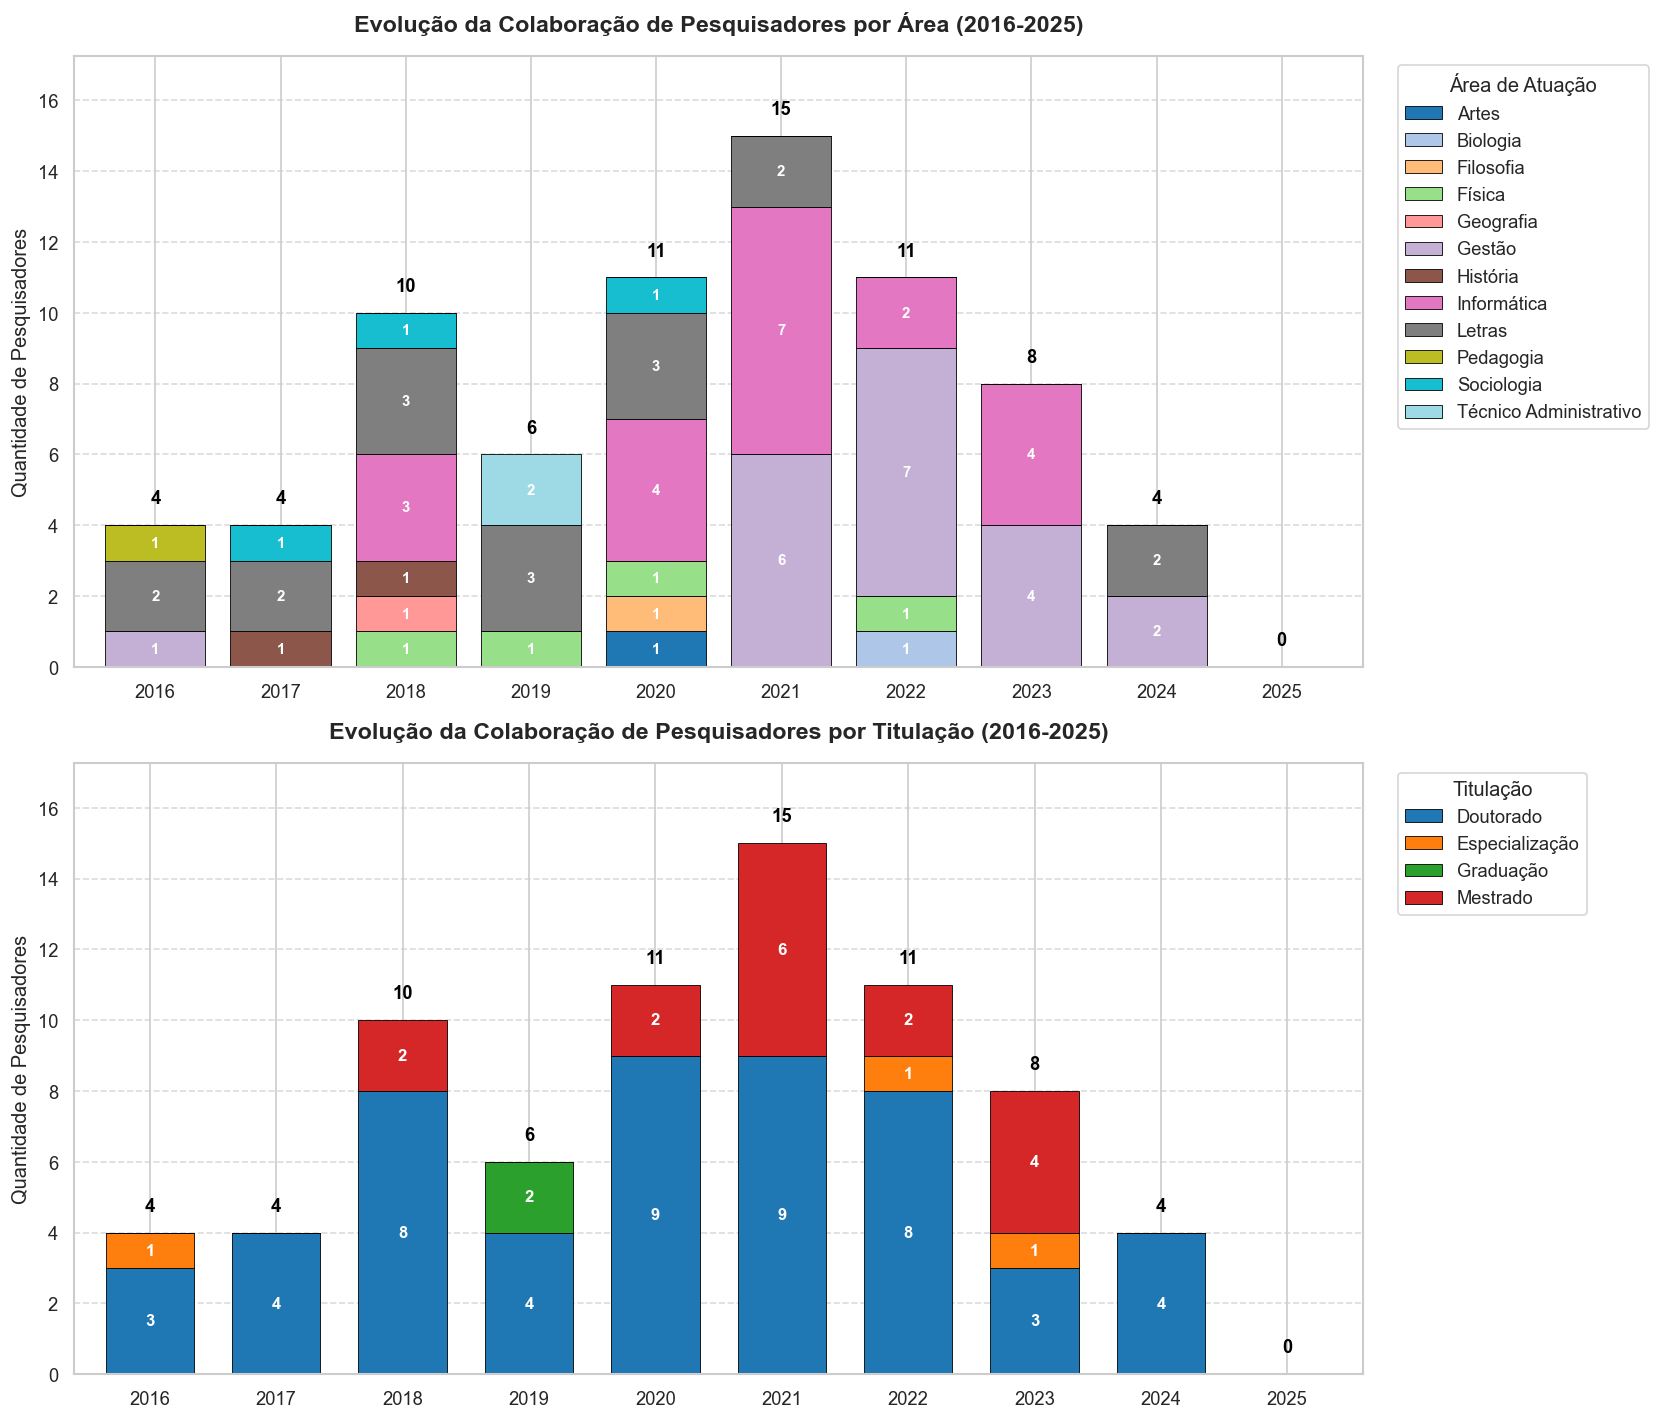

In [6]:
# ==============================================================================
# 8. VISUALIZAÇÃO: EVOLUÇÃO DEMOGRÁFICA DE PESQUISADORES ATIVOS
# ==============================================================================
# Somamos os nós ativos por ano, agrupados por Área e por Titulação, e transpomos (T)
df_area_year = df_preexisting_nodes.groupby('Área')[years_cols].sum().T
df_education_year = df_preexisting_nodes.groupby('Titulação')[years_cols].sum().T

# Removemos as categorias (colunas) que ficaram com zero em todos os anos
df_area_year = df_area_year.loc[:, df_area_year.sum(axis=0) > 0]
df_education_year = df_education_year.loc[:, df_education_year.sum(axis=0) > 0]

# Configuração da Figura (Painel com 2 gráficos empilhados)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), dpi=120)

# ================= GRÁFICO A: EVOLUÇÃO POR ÁREA =================
df_area_year.plot.bar(
    ax=axes[0], stacked=True, colormap='tab20', width=0.8, 
    edgecolor='black', linewidth=0.5
)
axes[0].set_title('Evolução da Colaboração de Pesquisadores por Área (2016-2025)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Quantidade de Pesquisadores', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend(title='Área de Atuação', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# ---> Adicionando os rótulos internos (Fatias)
for container in axes[0].containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    axes[0].bar_label(container, labels=labels, label_type='center', color='white', fontsize=9, fontweight='bold')

# ---> Adicionando o Total no Topo
totais_area = df_area_year.sum(axis=1)
axes[0].set_ylim(0, totais_area.max() * 1.15) 
for i, total in enumerate(totais_area):
    axes[0].text(i, total + 0.5, f'{int(total)}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')


# ================= GRÁFICO B: EVOLUÇÃO POR TITULAÇÃO =================
cores_titulacao = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#7f7f7f'] 
df_education_year.plot.bar(
    ax=axes[1], stacked=True, color=cores_titulacao[:len(df_education_year.columns)], width=0.7, 
    edgecolor='black', linewidth=0.5
)
axes[1].set_title('Evolução da Colaboração de Pesquisadores por Titulação (2016-2025)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Quantidade de Pesquisadores', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend(title='Titulação', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

# ---> Adicionando os rótulos internos (Fatias)
for container in axes[1].containers:
    labels = [f'{int(v.get_height())}' if v.get_height() > 0 else '' for v in container]
    axes[1].bar_label(container, labels=labels, label_type='center', color='white', fontsize=10, fontweight='bold')

# ---> Adicionando o Total no Topo
totais_titulacao = df_education_year.sum(axis=1)
axes[1].set_ylim(0, totais_titulacao.max() * 1.15)
for i, total in enumerate(totais_titulacao):
    axes[1].text(i, total + 0.5, f'{int(total)}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig('../assets/img/collaboration_evolution.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

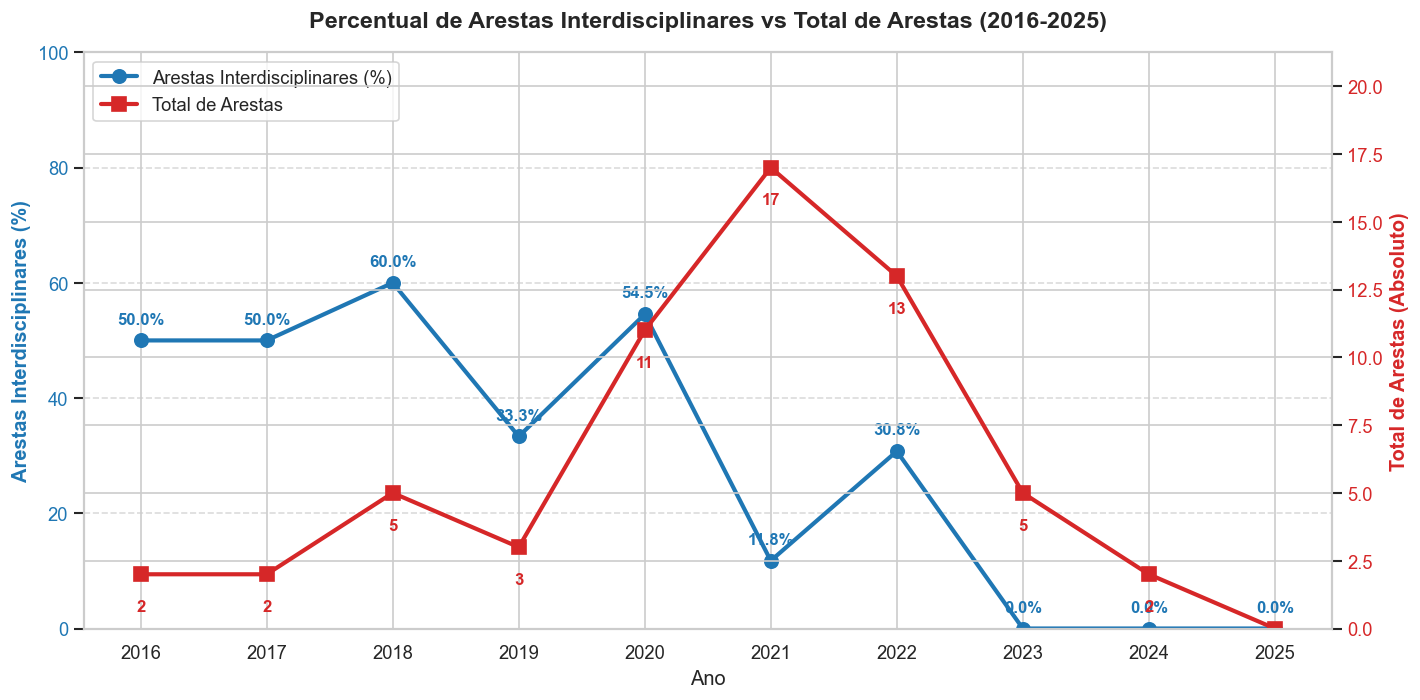

In [7]:
# ==============================================================================
# 9. VISUALIZAÇÃO: INTERDISCIPLINARIDADE VS TOTAL DE ARESTAS
# ==============================================================================
# 1. Somatórios Absolutos
total_edges_year = df_preexisting_edges[years_cols].sum()
inter_edges_year = df_preexisting_edges[df_preexisting_edges['Interdisciplinar'] == 1][years_cols].sum()

# 2. Cálculo do Percentual (Tratando divisão por zero elegantemente)
pct_interdisc = (inter_edges_year / total_edges_year.replace(0, np.nan)) * 100
pct_interdisc = pct_interdisc.fillna(0)

# 3. Configuração do Gráfico de Eixo Duplo (Dual Axis)
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=120)

# --- Eixo Y Principal (Esquerda) - Percentual (%) ---
color1 = '#1f77b4' # Azul
ax1.plot(years_cols, pct_interdisc, color=color1, marker='o', linewidth=2.5, markersize=8, label='Arestas Interdisciplinares (%)')
ax1.set_xlabel('Ano', fontsize=12)
ax1.set_ylabel('Arestas Interdisciplinares (%)', color=color1, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 100) 

# Anotações nas bolinhas azuis (Porcentagem)
for i, valor in enumerate(pct_interdisc):
    ax1.annotate(f'{valor:.1f}%', 
                 (years_cols[i], valor), 
                 textcoords="offset points", 
                 xytext=(0, 10), # Desloca 10 pontos para CIMA
                 ha='center', fontsize=10, fontweight='bold', color=color1)

# --- Eixo Y Secundário (Direita) - Total Absoluto ---
ax2 = ax1.twinx()
color2 = '#d62728' # Vermelho
ax2.plot(years_cols, total_edges_year, color=color2, marker='s', linewidth=2.5, markersize=8, label='Total de Arestas')
ax2.set_ylabel('Total de Arestas (Absoluto)', color=color2, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, total_edges_year.max() * 1.25) # Respiro extra para caber os números

# Anotações nos quadrados vermelhos (Total)
for i, valor in enumerate(total_edges_year):
    # Condição para não imprimir zero, mantendo o gráfico mais limpo
    texto = f'{int(valor)}' if valor > 0 else ''
    ax2.annotate(texto, 
                 (years_cols[i], valor), 
                 textcoords="offset points", 
                 xytext=(0, -15), # Desloca 15 pontos para BAIXO
                 ha='center', va='top', fontsize=10, fontweight='bold', color=color2)

# --- Título e Formatação Geral ---
plt.title('Percentual de Arestas Interdisciplinares vs Total de Arestas (2016-2025)', fontsize=14, fontweight='bold', pad=15)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Unificar as legendas ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('../assets/img/interdisciplinary_edges.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Avaliação do modelo: composição demográfica e estrutural

In [8]:
# ==============================================================================
# 10. CONSTRUÇÃO DOS GRAFOS E MÉTRICAS TOPOLÓGICAS
# ==============================================================================
print(">>> Calculando métricas topológicas das redes...")

# 1. Grafo Histórico (Preexistentes)
# Recalculamos o total absoluto somando as colunas dos anos
df_preexisting_edges['Total de Colaborações'] = df_preexisting_edges[years_cols].sum(axis=1)

G_preexisting = nx.Graph()
for idx, row in df_preexisting_edges.iterrows():
    p1, p2 = idx
    if row['Total de Colaborações'] > 0:
        G_preexisting.add_edge(p1, p2, weight=row['Total de Colaborações'])
        
# 2. Grafo de Sugestões (Modelo)
df_sugestoes = pd.read_parquet(PATH_SUGESTOES)
df_sugestoes.index = df_sugestoes.columns

# Prevenção de auto-conexão (Read-Only safe)
mask_diagonal = np.eye(len(df_sugestoes), dtype=bool)
df_sugestoes = df_sugestoes.mask(mask_diagonal, 0)

# Filtra arestas pelo limiar estatístico do modelo
G_suggestions = nx.from_pandas_adjacency(df_sugestoes > SUGGEST_THRESHOLD)
G_suggestions.remove_nodes_from(list(nx.isolates(G_suggestions)))

# Função auxiliar para Grau Médio
def calc_avg_degree(G):
    if G.number_of_nodes() == 0: return 0
    return sum(dict(G.degree()).values()) / G.number_of_nodes()

# 3. Consolidação das Métricas
metrics_dict = {
    'Preexistentes': {
        'Nós': G_preexisting.number_of_nodes(),
        'Arestas': G_preexisting.number_of_edges(),
        'Grau Médio': calc_avg_degree(G_preexisting),
        'Densidade': nx.density(G_preexisting),
        'Assortatividade': nx.degree_assortativity_coefficient(G_preexisting)
    },
    'Sugestões': {
        'Nós': G_suggestions.number_of_nodes(),
        'Arestas': G_suggestions.number_of_edges(),
        'Grau Médio': calc_avg_degree(G_suggestions),
        'Densidade': nx.density(G_suggestions),
        'Assortatividade': nx.degree_assortativity_coefficient(G_suggestions)
    }
}

df_metrics = pd.DataFrame(metrics_dict)
print("✅ Métricas calculadas e consolidadas com sucesso!\n")
display(df_metrics.round(4))

>>> Calculando métricas topológicas das redes...
✅ Métricas calculadas e consolidadas com sucesso!



,Preexistentes,Sugestões
Nós,40.0000,25.0000
Arestas,49.0000,25.0000
Grau Médio,2.4500,2.0000
Densidade,0.0628,0.0833
Assortatividade,-0.0449,-0.0999


In [9]:
# ==============================================================================
# 11. FUNÇÕES AUXILIARES DE DEMOGRAFIA
# ==============================================================================

# Função que varre a rede e conta as categorias sem duplicidade
def get_absolute_count(G, atributo_dict, nome_coluna):
    df = pd.DataFrame(list(G.nodes()), columns=['Pesquisador'])
    df['Pesquisador_norm'] = df['Pesquisador'].apply(normalize_name)
    
    atributo_dict_norm = {normalize_name(k): v for k, v in atributo_dict.items()}
    df['Atributo'] = df['Pesquisador_norm'].map(atributo_dict_norm)
    
    return df['Atributo'].dropna().value_counts().rename(nome_coluna)

In [10]:
# ==============================================================================
# 12. TABELAS DE RESUMO GLOBAL (INDIVÍDUOS ÚNICOS)
# ==============================================================================
print("\n>>> Resumo Global de Pesquisadores Únicos (Preexistentes vs Sugestões):")

# Tabela Área
hist_area = get_absolute_count(G_preexisting, areas_dict, 'Preexistentes')
sug_area = get_absolute_count(G_suggestions, areas_dict, 'Sugestões')
df_area_total = pd.concat([hist_area, sug_area], axis=1).fillna(0).astype(int)
df_area_t = df_area_total.T.sort_index(axis=1)
df_area_t.index.name = 'Grafo de Colaboração'
df_area_t['Total'] = df_area_t.sum(axis=1)

# Tabela Titulação
hist_education = get_absolute_count(G_preexisting, education_clean_dict, 'Preexistentes')
sug_education = get_absolute_count(G_suggestions, education_clean_dict, 'Sugestões')
df_education_total = pd.concat([hist_education, sug_education], axis=1).fillna(0).astype(int)
df_education_t = df_education_total.T.sort_index(axis=1)
df_education_t.index.name = 'Grafo de Colaboração'
df_education_t['Total'] = df_education_t.sum(axis=1)

print("\n--- Por Área de Atuação (Indivíduos Únicos) ---")
display(df_area_t)

print("\n--- Por Titulação (Indivíduos Únicos) ---")
display(df_education_t)


>>> Resumo Global de Pesquisadores Únicos (Preexistentes vs Sugestões):

--- Por Área de Atuação (Indivíduos Únicos) ---


Atributo,Artes,Biologia,Filosofia,Física,Geografia,Gestão,História,Informática,Letras,Matemática,Pedagogia,Sociologia,Técnico Administrativo,Total
Grafo de Colaboração,,,,,,,,,,,,,,
Preexistentes,1,1,1,2,1,11,1,10,8,0,1,1,2,40
Sugestões,0,1,0,2,0,6,1,1,3,5,5,1,0,25



--- Por Titulação (Indivíduos Únicos) ---


Atributo,Doutorado,Especialização,Graduação,Mestrado,Total
Grafo de Colaboração,,,,,
Preexistentes,26,2,2,10,40
Sugestões,19,1,0,5,25


>>> Processando cálculo de erro (RMSE) entre as redes...
✅ Cálculo do RMSE concluído e gráfico salvo com sucesso!



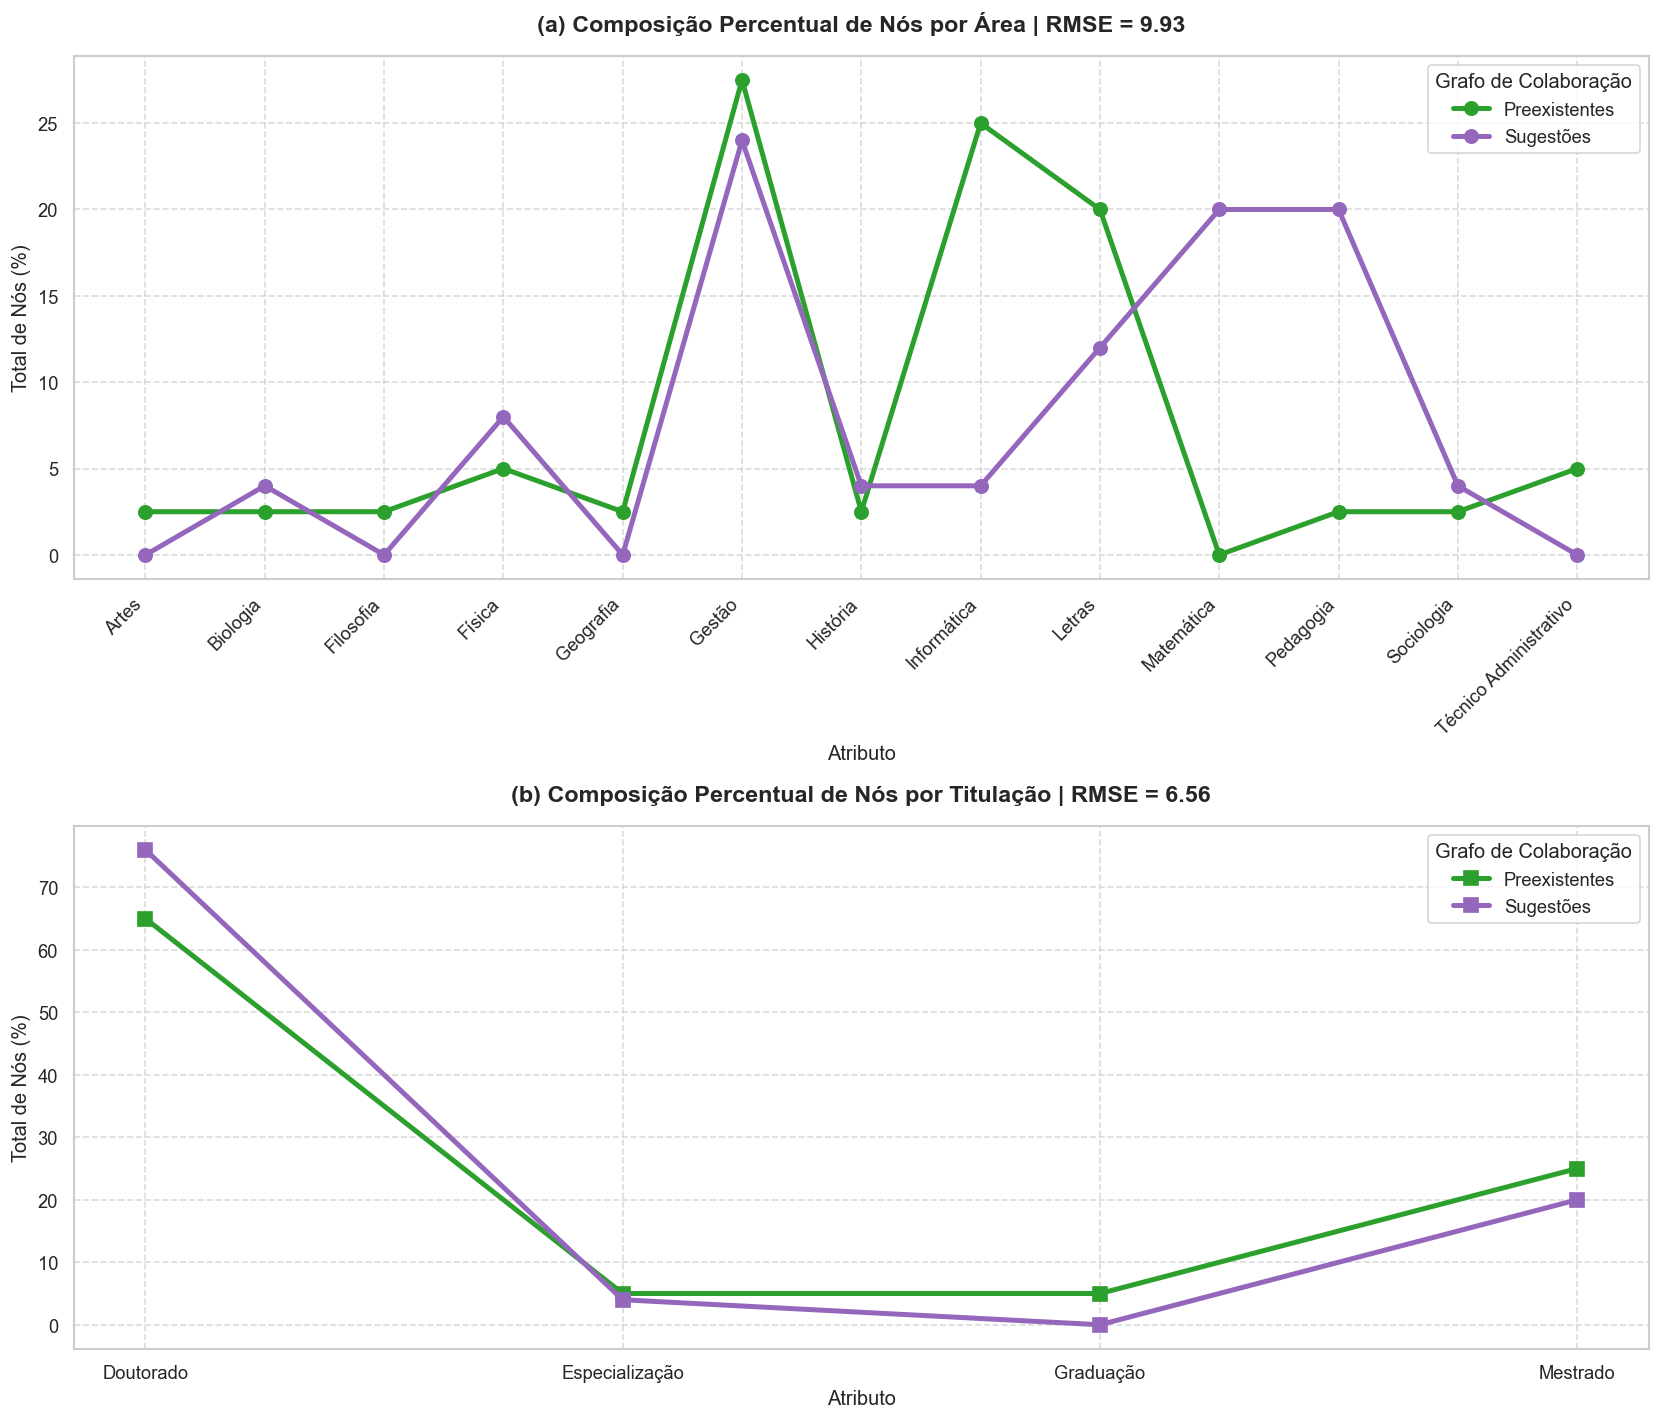

In [11]:
# ==============================================================================
# 13. VALIDAÇÃO DEMOGRÁFICA (CÁLCULO DE RMSE)
# ==============================================================================
print(">>> Processando cálculo de erro (RMSE) entre as redes...")

# Transformamos os absolutos (calculados acima) em percentuais para o RMSE
# Usamos sort_index() para ordenar os eixos X (Áreas e Titulações) em ordem alfabética
df_comp_area = (df_area_total / df_area_total.sum() * 100).sort_index()
df_comp_education = (df_education_total / df_education_total.sum() * 100).sort_index()

rmse_area = math.sqrt(mean_squared_error(df_comp_area['Preexistentes'], df_comp_area['Sugestões']))
rmse_education = math.sqrt(mean_squared_error(df_comp_education['Preexistentes'], df_comp_education['Sugestões']))

# Configuração da Figura (Painel com 2 gráficos de linhas)
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12), dpi=120)

# Gráfico A: Área
df_comp_area.plot.line(ax=axes[0], color=['#2ca02c', '#9467bd'], linewidth=3, marker='o', markersize=8)
axes[0].set_title(f'(a) Composição Percentual de Nós por Área | RMSE = {rmse_area:.2f}', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Total de Nós (%)', fontsize=12)
axes[0].set_xticks(range(len(df_comp_area)))
axes[0].set_xticklabels(df_comp_area.index, rotation=45, ha='right')
axes[0].grid(axis='both', linestyle='--', alpha=0.7)
axes[0].legend(title='Grafo de Colaboração', frameon=True)

# Gráfico B: Titulação
df_comp_education.plot.line(ax=axes[1], color=['#2ca02c', '#9467bd'], linewidth=3, marker='s', markersize=8)
axes[1].set_title(f'(b) Composição Percentual de Nós por Titulação | RMSE = {rmse_education:.2f}', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Total de Nós (%)', fontsize=12)
axes[1].set_xticks(range(len(df_comp_education)))
axes[1].set_xticklabels(df_comp_education.index, rotation=0)
axes[1].grid(axis='both', linestyle='--', alpha=0.7)
axes[1].legend(title='Grafo de Colaboração', frameon=True)

plt.tight_layout()
plt.savefig('../assets/img/nodes_composition.png', dpi=300, bbox_inches='tight', facecolor='white')

print("✅ Cálculo do RMSE concluído e gráfico salvo com sucesso!\n")
plt.show()

>>> Calculando a taxa de interdisciplinaridade global das redes...
• Rede Preexistente: 34.69% de arestas interdisciplinares
• Rede de Sugestões: 68.00% de arestas interdisciplinares


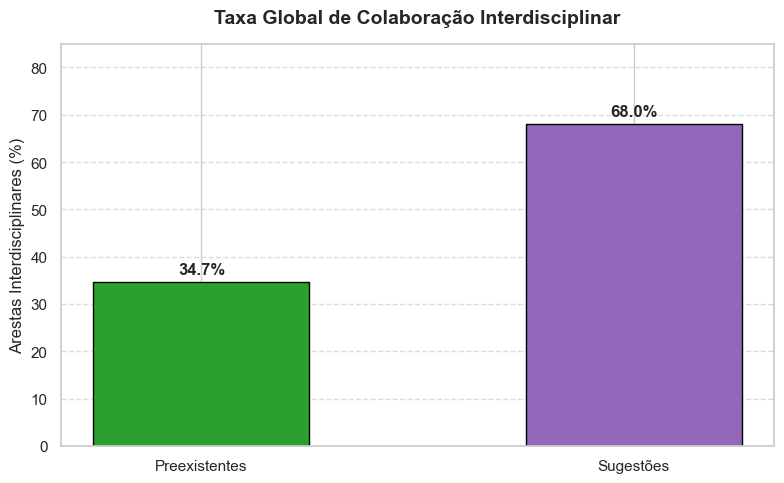

In [12]:
# ==============================================================================
# 14. COMPARAÇÃO DE INTERDISCIPLINARIDADE GLOBAL
# ==============================================================================
print(">>> Calculando a taxa de interdisciplinaridade global das redes...")

def calculate_interdisciplinarity(G, areas_dict):
    inter_count = 0
    total_edges = G.number_of_edges()
    
    # Prevenção de divisão por zero
    if total_edges == 0: return 0 
    
    for u, v in G.edges():
        # Voltamos a usar apenas o unidecode simples, exatamente como no seu backup,
        # para preservar as letras maiúsculas e dar match com o dicionário de áreas!
        area_u = areas_dict.get(unidecode(str(u).strip()), 'Desconhecida')
        area_v = areas_dict.get(unidecode(str(v).strip()), 'Desconhecida')
        
        if area_u != area_v:
            inter_count += 1
            
    return (inter_count / total_edges) * 100

# Execução do cálculo
inter_rate_hist = calculate_interdisciplinarity(G_preexisting, areas_dict)
inter_rate_sug = calculate_interdisciplinarity(G_suggestions, areas_dict)

# Saída no terminal (Estilo Log Analítico)
print(f"• Rede Preexistente: {inter_rate_hist:.2f}% de arestas interdisciplinares")
print(f"• Rede de Sugestões: {inter_rate_sug:.2f}% de arestas interdisciplinares")

# Visualização: Gráfico de Barras Comparativo
fig, ax = plt.subplots(figsize=(8, 5), dpi=100)
cores = ['#2ca02c', '#9467bd'] # Verde para Real, Roxo para Modelo
barras = ax.bar(['Preexistentes', 'Sugestões'], [inter_rate_hist, inter_rate_sug], 
                color=cores, width=0.5, edgecolor='black', linewidth=1)

ax.set_title('Taxa Global de Colaboração Interdisciplinar', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Arestas Interdisciplinares (%)', fontsize=12)
ax.set_ylim(0, max(inter_rate_hist, inter_rate_sug) * 1.25) # Respiro no topo
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona o valor percentual exato acima de cada barra
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width()/2., altura + 1,
            f'{altura:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../assets/img/interdisciplinarity_rates.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

>>> Analisando a topologia de conectividade das redes...


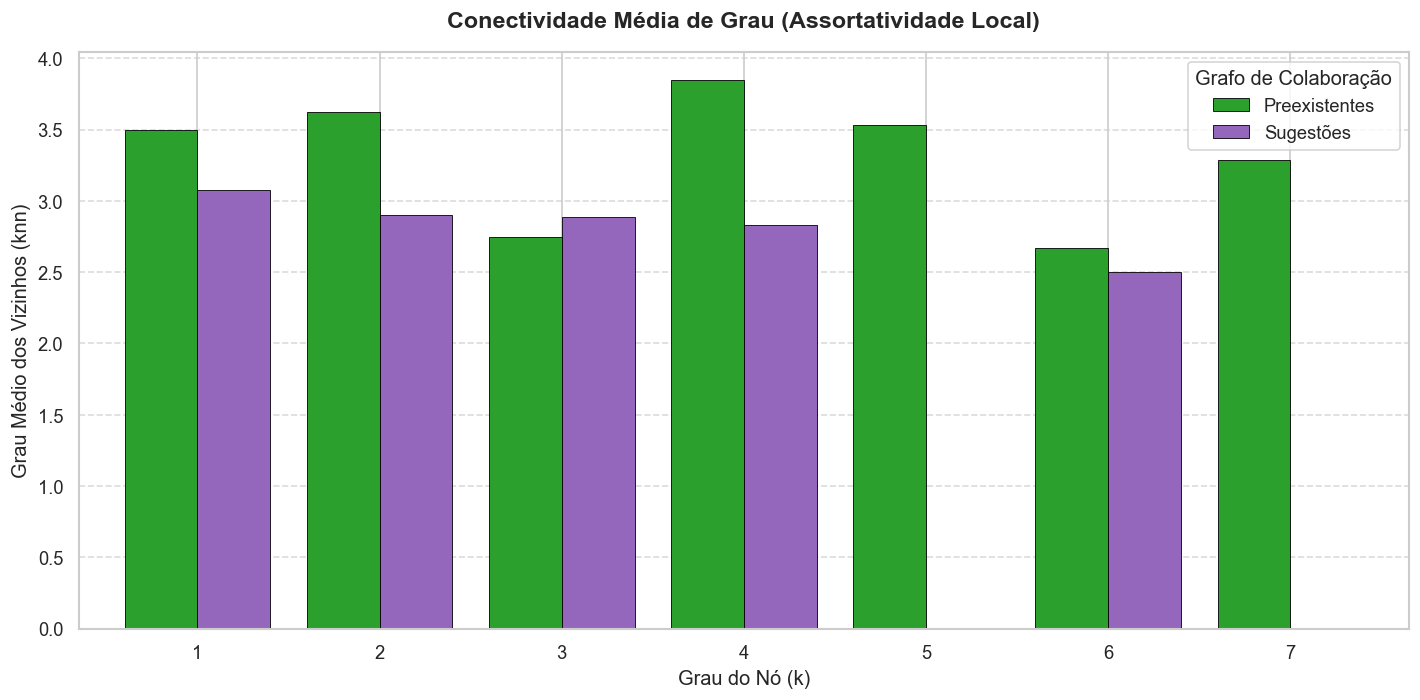

In [13]:
# ==============================================================================
# 15. COMPARAÇÃO ESTRUTURAL: CONECTIVIDADE MÉDIA DE GRAU
# ==============================================================================
print(">>> Analisando a topologia de conectividade das redes...")

# O NetworkX devolve um dicionário {grau: grau_médio_dos_vizinhos}
connect_hist = pd.Series(nx.average_degree_connectivity(G_preexisting)).sort_index()
connect_sug = pd.Series(nx.average_degree_connectivity(G_suggestions)).sort_index()

# Combina as duas séries num único DataFrame para alinhar os índices (graus) lado a lado
df_connect = pd.DataFrame({
    'Preexistentes': connect_hist,
    'Sugestões': connect_sug
}).fillna(0) # Preenche com 0 onde um grau existe numa rede mas não na outra

# Visualização: Gráfico de Barras Agrupadas
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

cores = ['#2ca02c', '#9467bd'] # Verde para Histórico, Roxo para Modelo
df_connect.plot.bar(ax=ax, color=cores, width=0.8, edgecolor='black', linewidth=0.5)

ax.set_title('Conectividade Média de Grau (Assortatividade Local)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Grau do Nó (k)', fontsize=12)
ax.set_ylabel('Grau Médio dos Vizinhos (knn)', fontsize=12)
ax.tick_params(axis='x', rotation=0) # Mantém os números do eixo X retos e fáceis de ler
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Grafo de Colaboração', loc='upper right', frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig('../assets/img/average_degree_connectivities.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

# Detecção e exportação de comunidades (Louvain)

In [14]:
# ==============================================================================
# 16. DETECÇÃO E EXPORTAÇÃO DE COMUNIDADES (LOUVAIN)
# ==============================================================================
print(">>> Detectando comunidades via Louvain e exportando para CSV...")

# Garante que a pasta de destino existe
DIR_OUTPUT = f'{BASE_PATH}/processed/communities'
os.makedirs(DIR_OUTPUT, exist_ok=True)

def export_communities_csv(G, file_prefix):
    # O Louvain encontra as partições maximizando a modularidade
    communities = nx_comm.louvain_communities(G, weight='weight', seed=42)
    print(f" • Rede '{file_prefix}': Encontradas {len(communities)} comunidades (clusters).")
    
    for i, com in enumerate(communities, 1):
        # Cria um DataFrame apenas com a coluna solicitada ('Pesquisador')
        df_comm = pd.DataFrame(list(com), columns=['Pesquisador'])
        
        # Caminho de salvamento seguro
        caminho = os.path.join(DIR_OUTPUT, f'{file_prefix}_community_{i}.csv')
        df_comm.to_csv(caminho, index=False, encoding='utf-8')

# 1. Exporta as comunidades do histórico real
export_communities_csv(G_preexisting, 'pre_existing')

# 2. Exporta as comunidades criadas pelo modelo de sugestões
export_communities_csv(G_suggestions, 'suggestions')

print(f"\n✅ Arquivos CSV gerados com sucesso na pasta: '{DIR_OUTPUT}'!")

>>> Detectando comunidades via Louvain e exportando para CSV...
 • Rede 'pre_existing': Encontradas 7 comunidades (clusters).
 • Rede 'suggestions': Encontradas 6 comunidades (clusters).

✅ Arquivos CSV gerados com sucesso na pasta: '../data/processed/communities'!
